In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Usando: cuda
GPU: NVIDIA GeForce RTX 2060
VRAM disponible: 6.4 GB


### Dataset Preprocessing Methods

In [34]:
#Eliminar sensores constantes
def eliminar_constantes(df, umbral_std=0.01):
    sensor_cols = [c for c in df.columns if c.startswith("s")]
    std = df[sensor_cols].std()
    constantes = std[std < umbral_std].index.tolist()
    print(f"Sensores eliminados por baja varianza: {constantes}")
    return df.drop(columns=constantes), constantes

#Calcular y añadir la etiqueta RUL
def add_rul_train(df, rul_max=110):
    """
    RUL real = ciclos restantes hasta el fallo.
    Se trunca a rul_max (cap lineal): permite que el modelo se centre en los ciclos 
    cercanos al fallo. No hay necesidad de predecir el fallo desde el inicio del trayecto.
    """
    max_ciclo = df.groupby("motor_id")["ciclo"].max().rename("ciclo_max")
    df = df.join(max_ciclo, on="motor_id")
    df["rul"] = (df["ciclo_max"] - df["ciclo"]).clip(upper=rul_max)
    df = df.drop(columns=["ciclo_max"])
    return df

def add_rul_test(df, rul_finales, rul_max=110):
    """
    En test, NASA proporciona cuántos ciclos quedaban al final
    del fragmento observado. Se suman los ciclos restantes y se calcula
    el RUL para cada ciclo de cada motor
    """
    rul_map = {
        motor_id + 1: rul
        for motor_id, rul in enumerate(rul_finales["rul_final"].values)
    }
    max_ciclo = df.groupby("motor_id")["ciclo"].max()
    
    def rul_para_motor(row):
        rul_final = rul_map[row["motor_id"]]
        ciclos_restantes = (max_ciclo[row["motor_id"]] - row["ciclo"]) + rul_final
        return min(ciclos_restantes, rul_max)
    
    df["rul"] = df.apply(rul_para_motor, axis=1)
    return df

def norm(train_df, test_df, feature_cols):
    """
    MinMaxScaler ajustado SOLO sobre train.
    Aplica la misma transformación a test sin re-ajustar.
    """
    scaler = MinMaxScaler(feature_range=(0, 1))
    
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols] = scaler.transform(test_df[feature_cols]) 
    
    return train_df, test_df, scaler

def crear_ventanas(df, feature_cols, window_size=30):
    """
    Para cada motor, recorre sus ciclos con una ventana de tamaño window_size.
    Si el motor tiene menos ciclos que window_size, se rellena con padding
    al principio (ceros)
    
    Devuelve:
        X: (N, window_size, n_features)
        y: (N,)  — RUL en el último ciclo de cada ventana
    """
    X_list, y_list = [], []
    
    for motor_id, motor in df.groupby("motor_id"):
        datos = motor[feature_cols].values   # (ciclos, n_features)
        etiqueta = motor["rul"].values           # (ciclos,)
        n_ciclos = len(datos)
        
        if n_ciclos < window_size:
            # Padding al principio con ceros
            pad = np.zeros((window_size - n_ciclos, datos.shape[1]))
            datos = np.vstack([pad, datos])
            etiqueta = np.concatenate([np.full(window_size - n_ciclos, etiqueta[0]), etiqueta])
            n_ciclos = window_size
        
        for i in range(n_ciclos - window_size + 1):
            X_list.append(datos[i : i + window_size])
            y_list.append(etiqueta[i + window_size - 1])   # RUL del último ciclo
    
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def crear_ventanas_test(df, feature_cols, window_size=30):
    """
    Se usa la última ventana de cada motor
    """
    X_list, y_list = [], []
    
    for motor_id, motor in df.groupby("motor_id"):
        datos = motor[feature_cols].values
        etiqueta = motor["rul"].values
        n_ciclos = len(datos)
        
        if n_ciclos >= window_size:
            X_list.append(datos[-window_size:])
        else:
            pad = np.zeros((window_size - n_ciclos, datos.shape[1]))
            ventana = np.vstack([pad, datos])
            X_list.append(ventana)
        
        y_list.append(etiqueta[-1])
    
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


### Features de degradación

In [35]:
#Crear una desviación para cada sensor respecto del inicio de los ciclos
def add_degradation_features(df,feature_cols,window_slope=10, suavizado=3):
    """
    Añadir un índice de cambio respecto al inicio de la medición.
    Cuando el cambio es grande => mayor degradación.
    Añadir un slope respecto de la anterior ventana (sub-ventana de entrenamiento)
    Añadir una aceleración de degradación, indicar si los valores están cambiando rápido o despacio.
    Ignorar op_n ya que no indican degradación, indican el régimen de vuelo que se está llevando a cabo.
    """
    df = df.copy()
    for motor_id, motor in df.groupby("motor_id"):
        idx = motor.index
        for sensor in feature_cols:
            # add variación de valor entre el primer ciclo y el n-ciclo
            value = motor[sensor].values
            delta = value - value[0]
            df.loc[idx,f"{sensor}_delta"] = delta 

            # add slope respecto a la anterior ventana
            slope = np.zeros(len(value))
            for t in range(len(value)):
                inicio = max(0, t - window_slope + 1)
                ventana = value[inicio : t + 1]
                if len(ventana) >= 3:   
                    x = np.arange(len(ventana))
                    slope[t] = stats.linregress(x, ventana).slope # la pendiente de la recta que mejor ajusta los valores del sensor en una ventana
                else:
                    slope[t] = 0.0
            df.loc[idx, f"{sensor}_slope"] = slope

            # add aceleración, se suaviza el slope para reducir ruido
            slope_suav = pd.Series(slope).rolling(
                window=suavizado, min_periods=1
            ).mean().values
            accel = np.gradient(slope_suav)  
            df.loc[idx, f"{sensor}_accel"] = accel

    return df

def añadir_features_degradacion_rapido(df, sensor_cols, window_slope=10, suavizado=3):
    """
    Versión vectorizada — entre 20x y 50x más rápida que la versión con bucles.
    
    La clave es operar sobre columnas enteras en lugar de valor a valor:
    - delta:  una resta de arrays
    - slope:  rolling OLS vectorizado con fórmula analítica
    - accel:  diff sobre el slope suavizado
    """
    df = df.copy().sort_values(["motor_id", "ciclo"])
    result_chunks = []
    
    for motor_id, grupo in df.groupby("motor_id", sort=False):
        chunk = grupo.copy()
        n = len(chunk)
    
        for col in sensor_cols:
            serie = chunk[col].values  # array NumPy — operaciones vectorizadas
    
            # ── Delta: resta directa, sin bucle ───────────────────────────
            chunk[f"{col}_delta"] = serie - serie[0]
    
            # ── Slope: OLS analítico vectorizado ──────────────────────────
            # En una ventana [t-w+1 .. t], la pendiente OLS es:
            #   slope = (Σ(x-x̄)(y-ȳ)) / (Σ(x-x̄)²)
            # donde x son los índices 0..w-1, constantes para todas las ventanas
            # Esto se puede calcular con rolling sobre toda la columna de una vez
            s = pd.Series(serie)
    
            # Precomputar denominador — es constante para ventanas completas
            # x = [0, 1, ..., w-1], x̄ = (w-1)/2
            # Σ(x-x̄)² = w*(w²-1)/12  (fórmula cerrada)
            w = window_slope
            x_mean = (w - 1) / 2.0
            denom  = w * (w**2 - 1) / 12.0  # escalar, se calcula una vez
    
            # Numerador: rolling covarianza entre índices y valores
            # Σ(x-x̄)(y-ȳ) = Σ(x·y) - w·x̄·ȳ
            # Σ(x·y) con x=[0..w-1]: se puede expresar como suma ponderada
            weights_x = np.arange(w, dtype=np.float64) - x_mean  # (w,)
    
            # rolling_apply sobre toda la serie — una sola llamada
            def slope_ventana(y_ventana):
                if len(y_ventana) < 3:
                    return 0.0
                y_c = y_ventana - y_ventana.mean()
                return np.dot(weights_x[-len(y_ventana):], y_c) / denom
    
            slope = (s.rolling(window=w, min_periods=3)
                      .apply(slope_ventana, raw=True)
                      .fillna(0.0)
                      .values)
            chunk[f"{col}_slope"] = slope
    
            # ── Aceleración: diff del slope suavizado ─────────────────────
            slope_suav = (pd.Series(slope)
                           .rolling(window=suavizado, min_periods=1)
                           .mean()
                           .values)
            chunk[f"{col}_accel"] = np.gradient(slope_suav)
    
        result_chunks.append(chunk)
    
    return pd.concat(result_chunks, ignore_index=True)

### Construcción del modelo

In [47]:

# ── Dataset ─────────────────────────────────────────────────────────────────

class CMAPSSDataset(Dataset):
    def __init__(self, X, y, pesos=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.pesos = torch.tensor(pesos, dtype=torch.float32) \
                     if pesos is not None else torch.ones(len(y))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.pesos[idx]


# ── Atención Bahdanau ────────────────────────────────────────────────────────

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim, attn_units=64):
        super().__init__()
        self.W = nn.Linear(hidden_dim, attn_units)
        self.v = nn.Linear(attn_units, 1, bias=False)

    def forward(self, h):
        # h: (batch, T, hidden_dim)
        score   = self.v(torch.tanh(self.W(h)))        # (batch, T, 1)
        weights = torch.softmax(score, dim=1)           # (batch, T, 1)
        context = torch.sum(weights * h, dim=1)         # (batch, hidden_dim)
        return context, weights


# ── Modelo completo ──────────────────────────────────────────────────────────

class CNNBiLSTMAttention(nn.Module):
    def __init__(self, n_features, window_size=30,
                 cnn_filtros=64, lstm_units=64,
                 attn_units=64, dropout=0.3):
        super().__init__()

        # ── CNN 1D ──────────────────────────────────────────────────────────
        # En PyTorch Conv1d espera (batch, channels, length)
        # Entrada: (batch, window_size, n_features) → permutar antes de Conv1d
        self.cnn = nn.Sequential(
            nn.Conv1d(n_features, cnn_filtros, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filtros),
            nn.ReLU(),
            nn.Conv1d(cnn_filtros, cnn_filtros, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_filtros),
            nn.ReLU(),
            nn.Conv1d(cnn_filtros, cnn_filtros, kernel_size=3,
                      padding=2, dilation=2),
            nn.BatchNorm1d(cnn_filtros),
            nn.ReLU(),
        )

        # ── BiLSTM ──────────────────────────────────────────────────────────
        # Entrada tras CNN: (batch, window_size, cnn_filtros)
        self.bilstm1 = nn.LSTM(
            input_size   = cnn_filtros,
            hidden_size  = lstm_units,
            batch_first  = True,
            bidirectional= True,
        )
        
        self.bilstm2 = nn.LSTM(
            input_size   = lstm_units * 2,   # *2 por bidireccional
            hidden_size  = lstm_units,
            batch_first  = True,
            bidirectional= True
        )
        self.dropout = nn.Dropout(dropout)

        # ── Atención ────────────────────────────────────────────────────────
        self.attention = BahdanauAttention(
            hidden_dim = lstm_units * 2,
            attn_units = attn_units
        )

        # ── Cabeza de regresión ──────────────────────────────────────────────
        self.fc = nn.Sequential(
            nn.Linear(lstm_units * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout), # generalizar
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, window_size, n_features)

        # CNN — necesita (batch, channels, length)
        x_cnn = x.permute(0, 2, 1)          # (batch, n_features, window_size)
        x_cnn = self.cnn(x_cnn)             # (batch, cnn_filtros, window_size)
        x_cnn = x_cnn.permute(0, 2, 1)      # (batch, window_size, cnn_filtros)

        # BiLSTM
        x_lstm, _ = self.bilstm1(x_cnn)     # (batch, window_size, lstm*2)
        x_lstm = self.dropout(x_lstm)
        x_lstm, _ = self.bilstm2(x_lstm)    # (batch, window_size, lstm*2)
        x_lstm = self.dropout(x_lstm)

        # Atención
        context, attn_w = self.attention(x_lstm)   # (batch, lstm*2)

        # Regresión
        out = self.fc(context)               # (batch, 1)
        return out.squeeze(-1), attn_w       # (batch,), (batch, T, 1)

### Nasa Score Loss

In [48]:
def nasa_score_loss(y_pred, y_true):
    diff = y_pred - y_true
    score = torch.where(
        diff < 0,
        torch.exp(-diff / 13.0) - 1,
        torch.exp( diff / 10.0) - 1
    )
    return score.mean()

def rmse(y_pred, y_true):
    return torch.sqrt(F.mse_loss(y_pred, y_true))

### Condiciones operacionales

In [49]:
def identificar_condicion_operacional(df, n_condiciones=6):
    """
    En FD002/FD004 hay 6 condiciones operacionales distintas.
    Las identificamos agrupando op_1, op_2, op_3 con KMeans.
    En FD001/FD003 con n_condiciones=1 asigna todo al cluster 0.
    """
    op_cols = ["op_1", "op_2", "op_3"]
    
    if n_condiciones == 1:
        df["condicion"] = 0
        return df
    
    km = KMeans(n_clusters=n_condiciones, random_state=42, n_init=10)
    df["condicion"] = km.fit_predict(df[op_cols])
    return df, km


def normalizar_por_condicion(train_df, test_df, feature_cols, n_condiciones):
    """
    Para FD002/FD004: ajusta un scaler distinto por condición operacional.
    Para FD001/FD003: normalización global (igual que antes).
    
    Esto evita que el modelo confunda variación por régimen de vuelo
    con variación por degradación.
    """
    train_df[feature_cols] = train_df[feature_cols].astype(np.float64)
    test_df[feature_cols]  = test_df[feature_cols].astype(np.float64)
    
    if n_condiciones == 1:
        scaler = MinMaxScaler()
        train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
        test_df[feature_cols]  = scaler.transform(test_df[feature_cols])
        return train_df, test_df, {0: scaler}
    
    scalers = {}
    for cond in range(n_condiciones):
        mask_train = train_df["condicion"] == cond
        mask_test = test_df["condicion"]  == cond
        
        if mask_train.sum() == 0:
            continue
            
        scaler = MinMaxScaler()
        train_df.loc[mask_train, feature_cols] = scaler.fit_transform(
            train_df.loc[mask_train, feature_cols]
        )
        if mask_test.sum() > 0:
            test_df.loc[mask_test, feature_cols] = scaler.transform(
                test_df.loc[mask_test, feature_cols]
            )
        scalers[cond] = scaler
    
    return train_df, test_df, scalers

### Dataset Preprocessing

In [50]:
CONFIG_DATASETS = {
    "FD001": {"n_condiciones": 1, "n_fallos": 1, "cnn_filtros": 64, "lstm_units": 64}, # Subset estable 
    "FD002": {"n_condiciones": 6, "n_fallos": 1, "cnn_filtros": 64, "lstm_units": 128}, # Subset con más condiciones => más tipos de degradación temporal
    "FD003": {"n_condiciones": 1, "n_fallos": 2, "cnn_filtros": 128, "lstm_units": 64}, # Más patrones posibles de degradación
    "FD004": {"n_condiciones": 6, "n_fallos": 2, "cnn_filtros": 128, "lstm_units": 128} # Ambos
}

In [51]:
def preparar_dataset_v3(ruta_base,subset,window_size=60, rul_max=110):

    config = CONFIG_DATASETS[subset]
    n_condiciones = config["n_condiciones"]

    COLS = (
    ["motor_id", "ciclo"] +
    [f"op_{i}" for i in range(1, 4)] +          # 3 configuraciones operacionales
    [f"s{i}" for i in range(1, 22)]             # 21 sensores
    )

    train = pd.read_csv(f"{ruta_base}/train_{subset}.txt", sep=r"\s+", header=None, names=COLS)
    test = pd.read_csv(f"{ruta_base}/test_{subset}.txt", sep=r"\s+", header=None, names=COLS)
    rul = pd.read_csv(f"{ruta_base}/RUL_{subset}.txt", sep=r"\s+", header=None, names=["rul_final"])
    
    train_df = add_rul_train(train.copy(), rul_max=rul_max)
    test_df = add_rul_test(test.copy(), rul, rul_max=rul_max)

    # Eliminar sensores constantes sobre train
    sensor_cols = [c for c in train_df.columns if c.startswith("s")]
    std = train_df[sensor_cols].std()
    constantes = std[std < 0.01].index.tolist()
    train_df = train_df.drop(columns=constantes)
    test_df = test_df.drop(columns=constantes)
    sensor_cols = [c for c in sensor_cols if c not in constantes]

    # Identificar condición operacional
    if n_condiciones > 1:
        train_df, km = identificar_condicion_operacional(train_df, n_condiciones)
        # Aplicar el mismo KMeans al test — no re-ajustar
        test_df["condicion"] = km.predict(test_df[["op_1","op_2","op_3"]])
    else:
        train_df = identificar_condicion_operacional(train_df, 1)
        test_df["condicion"] = 0

    # Columnas para calcular degradación 
    deg_cols = [c for c in train_df.columns if c.startswith("s")]
    
    # Features de degradación
    print(f"[{subset}] Calculando features de degradación...")
    train_df = añadir_features_degradacion_rapido(train_df, deg_cols)
    test_df = añadir_features_degradacion_rapido(test_df,  deg_cols)

    # Columnas que entran al modelo
    feature_cols = [c for c in train_df.columns if c.startswith("s") or c.startswith("op")]

    # Normalizar — por condición si FD002/FD004
    train_df, test_df, scalers = normalizar_por_condicion(train_df, test_df, feature_cols, n_condiciones)

    # Ventanas
    X_tr_full, y_tr_full = crear_ventanas(train_df, feature_cols, window_size)
    X_test, y_test = crear_ventanas_test(test_df, feature_cols, window_size)

    X_train, X_val, y_train, y_val = train_test_split(X_tr_full, y_tr_full, test_size=0.15, random_state=42)

    print(f"[{subset}] Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
    print(f"[{subset}] Features: {len(feature_cols)} | Condiciones: {n_condiciones}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), scalers, feature_cols

### Entrenamiento CNN + BiLSTM 

In [52]:
def entrenar(subset, ruta_base="../CMAPSSData",
             window_size=60, epochs=150, batch_size=256):

    cfg = CONFIG_DATASETS[subset]
    cnn_filtros = cfg["cnn_filtros"]
    lstm_units = cfg["lstm_units"]
    print(f"Parámetros de {subset}: cnn_filtros = {cnn_filtros}, lstm_units = {lstm_units}")
    
    
    # Datos
    (X_tr, y_tr), (X_val, y_val), (X_te, y_te), scalers, feats = \
        preparar_dataset_v3(ruta_base, subset, window_size)

    #pesos_tr = sample_weights(y_tr)

    train_loader = DataLoader(
        CMAPSSDataset(X_tr, y_tr), # Se ha quitado el pesos_tr
        batch_size=batch_size, shuffle=True,
        pin_memory=True,        # acelera transferencia CPU→GPU
        num_workers=4
    )
    val_loader = DataLoader(
        CMAPSSDataset(X_val, y_val),
        batch_size=batch_size, shuffle=False,
        pin_memory=True
    )

    # Modelo
    model = CNNBiLSTMAttention(
        n_features  = X_tr.shape[2],
        window_size = window_size,
        cnn_filtros = cnn_filtros,
        lstm_units  = lstm_units,
        attn_units  = 64,
        dropout     = 0.3
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.5, patience=8, min_lr=1e-6)

    mejor_val_rmse = float("inf")
    paciencia_actual = 0
    PACIENCIA_MAX = 20
    historial = {"train_loss": [], "val_loss": [], "val_rmse": []}

    for epoch in range(1, epochs + 1):

        # ── Entrenamiento ────────────────────────────────────────────────
        model.train()
        train_loss = 0.0

        for X_batch, y_batch, w_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            w_batch = w_batch.to(DEVICE)

            optimizer.zero_grad()
            y_pred, _ = model(X_batch)

            # Pérdida ponderada por sample_weights
            loss_por_muestra = torch.where(
                (y_pred - y_batch) < 0,
                torch.exp(-(y_pred - y_batch) / 13.0) - 1,
                torch.exp( (y_pred - y_batch) / 10.0) - 1
            )
            loss = (loss_por_muestra * w_batch).mean()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ── Validación ───────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        val_preds, val_true = [], []

        with torch.no_grad():
            for X_batch, y_batch, _ in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                y_pred, _ = model(X_batch)
                val_loss += nasa_score_loss(y_pred, y_batch).item()
                val_preds.append(y_pred.cpu())
                val_true.append(y_batch.cpu())

        val_loss /= len(val_loader)
        val_preds = torch.cat(val_preds)
        val_true  = torch.cat(val_true)
        val_rmse  = rmse(val_preds, val_true).item()

        scheduler.step(val_loss)
        historial["train_loss"].append(train_loss)
        historial["val_loss"].append(val_loss)
        historial["val_rmse"].append(val_rmse)

        if epoch % 10 == 0:
            lr_actual = optimizer.param_groups[0]["lr"]
            print(f"Época {epoch:>3} | train_loss {train_loss:.4f} | "
                  f"val_loss {val_loss:.4f} | val_rmse {val_rmse:.2f} | lr {lr_actual:.2e}")

        # ── Early stopping y checkpoint ──────────────────────────────────
        if val_rmse < mejor_val_rmse:
            mejor_val_rmse = val_rmse
            paciencia_actual = 0
            torch.save(model.state_dict(), f"mejor_modelo_{subset}.pt")
        else:
            paciencia_actual += 1
            if paciencia_actual >= PACIENCIA_MAX:
                print(f"Early stopping en época {epoch}")
                break

    # Cargar mejor checkpoint
    model.load_state_dict(torch.load(f"mejor_modelo_{subset}.pt"))
    return model, historial, (X_te, y_te)


def evaluar(model, X_test, y_test, subset):
    model.eval()
    X_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        y_pred, attn_w = model(X_tensor)

    y_pred = y_pred.cpu().numpy()
    diff   = y_pred - y_test

    score_por_motor = np.where(
        diff < 0,
        np.exp(-diff / 13.0) - 1,
        np.exp( diff / 10.0) - 1
    )

    print(f"\n── {subset} ──────────────────────────")
    print(f"RMSE  : {np.sqrt(np.mean(diff**2)):.2f}")
    print(f"MAE   : {np.mean(np.abs(diff)):.2f}")
    print(f"Score : {score_por_motor.sum():.1f}")

    return y_pred, attn_w.cpu().numpy()


# Entrenar los 4 datasets
for subset in ["FD001", "FD002", "FD003", "FD004"]:
    print(f"\n{'='*50}\nEntrenando {subset}...")
    model, hist, (X_te, y_te) = entrenar(subset)
    evaluar(model, X_te, y_te, subset)


Entrenando FD001...
Parámetros de FD001: cnn_filtros = 64, lstm_units = 64
[FD001] Calculando features de degradación...
[FD001] Train: (12521, 60, 59) | Val: (2210, 60, 59) | Test: (100, 60, 59)
[FD001] Features: 59 | Condiciones: 1
Época  10 | train_loss 1.7386 | val_loss 0.8800 | val_rmse 8.48 | lr 1.00e-03
Época  20 | train_loss 1.6539 | val_loss 0.9478 | val_rmse 9.00 | lr 1.00e-03
Época  30 | train_loss 1.5555 | val_loss 0.3651 | val_rmse 4.40 | lr 5.00e-04
Época  40 | train_loss 1.5202 | val_loss 0.5429 | val_rmse 6.00 | lr 5.00e-04
Época  50 | train_loss 1.4822 | val_loss 0.2511 | val_rmse 3.30 | lr 2.50e-04
Época  60 | train_loss 1.4746 | val_loss 0.3227 | val_rmse 3.95 | lr 1.25e-04
Época  70 | train_loss 1.4842 | val_loss 0.3307 | val_rmse 4.03 | lr 6.25e-05
Época  80 | train_loss 1.4794 | val_loss 0.3021 | val_rmse 3.84 | lr 3.13e-05
Early stopping en época 83

── FD001 ──────────────────────────
RMSE  : 14.19
MAE   : 10.91
Score : 256.5

Entrenando FD002...
Parámetros de 

## Visualización de datos: Justificación de Kmeans para los 6 condiciones de vuelo

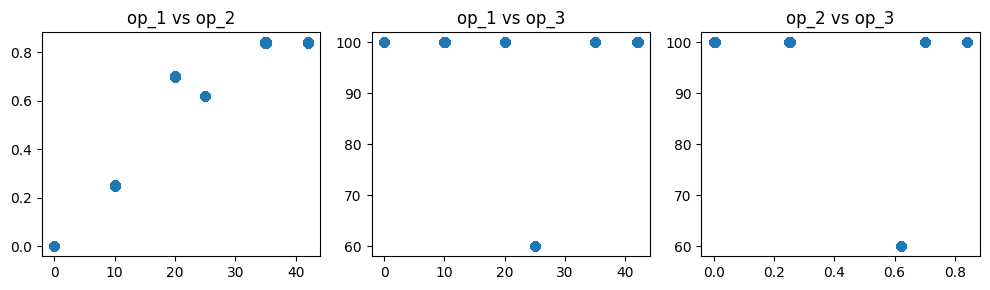

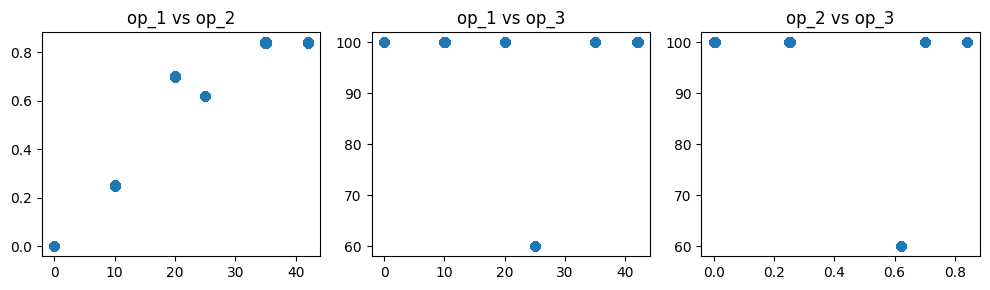

In [88]:
COLS = (
    ["motor_id", "ciclo"] +
    [f"op_{i}" for i in range(1, 4)] +          # 3 configuraciones operacionales
    [f"s{i}" for i in range(1, 22)]             # 21 sensores
    )
FD002 = pd.read_csv("../CMAPSSData/train_FD002.txt", sep=r"\s+", header=None, names=COLS)
FD004 = pd.read_csv("../CMAPSSData/train_FD004.txt", sep=r"\s+", header=None, names=COLS)

#display(op)
def inspeccionar_op(op):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    pares = [("op_1","op_2"), ("op_1","op_3"), ("op_2","op_3")]
    for ax, (x, y) in zip(axes, pares):
        ax.scatter(op[x], op[y])
        ax.set_title(f"{x} vs {y}")
    plt.tight_layout()
    plt.show()

inspeccionar_op(FD002[["op_1","op_2","op_3"]])
inspeccionar_op(FD004[["op_1","op_2","op_3"]])